In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [25]:
data = pd.read_csv('data.csv')

# Here, X_train will contain the two input features for each training examples.
# These will be 2d numpy array, where each element in the array is the list of the feature1 and feature 2 pairs for each training examples.
#X_train = data[['feature1', 'feature2']].values

# here, feature 1 = age, feature 2 = EstimatedSalary
X_train = data[['Age', 'EstimatedSalary']].values


# Here, y_train contains actual true class label for each example
# An array of elements that either 0 or 1
# y_train = data['label'].values
# here label is purchased
y_train = data['Purchased'].values

# here, here are 2 global variable m and n, 
# m is the number of training examples and 
# n is the number of input features
# these corresponds to the shape of the X_train data so

m, n = X_train.shape

### plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=20)

X_train[y_train == 0, 0] → Selects feature1 (Age) for all training examples where Purchased == 0

X_train[y_train == 0, 1] → Selects feature2 (Salary) for all training examples where Purchased == 0

color='tab:blue' → Makes these points blue

label='Class 0' → Labels as "Class 0" for legend (people who did NOT purchase)

s=20 → Point size = 20 pixels


### plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=20)
X_train[y_train == 1, 0] → Selects feature1 (Age) for examples where Purchased == 1

X_train[y_train == 1, 1] → Selects feature2 (Salary) for examples where Purchased == 1

color='tab:orange' → Makes these points orange

label='Class 1' → Labels as "Class 1" (people who DID purchase)


plt.legend()  # Shows the color coding (blue = Class 0, orange = Class 1)
plt.show()  # Renders and shows the plot


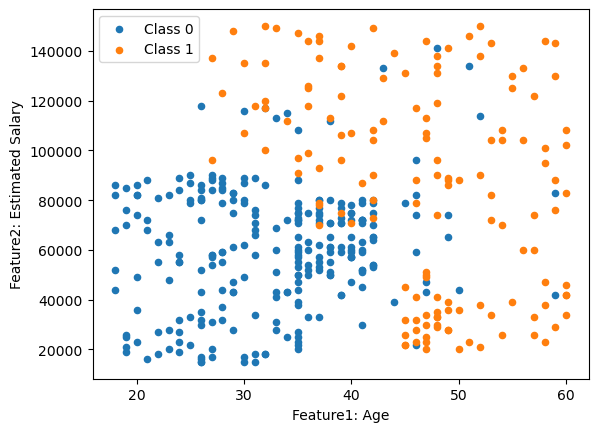

In [26]:
# Let's use scatter plot(2d) to visualize how the two features seperate in the two class( Purchased = 0 or 1)


plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=20)
plt.xlabel('Feature1: Age')
plt.ylabel('Feature2: Estimated Salary')
plt.legend()
plt.show()

# Implementation Plan

1. **Sigmoid Function**: Returns our probability output between 0 and 1  

2. **Cost Function**: Measures how well our model is performing  

3. **Gradient Function**: Computes derivatives of the cost function with respect to parameters  

4. **Gradient Descent Function**: Updates parameters iteratively to minimize the cost function  

5. **Predict Function**: Returns predicted class (0 or 1) for each training example

1. **Sigmoid Function**: Returns our probability output between 0 and 1  


In [27]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# this gives us the values between 0 and 1

2. **Cost Function**: Measures how well our model is performing  


In [28]:
def cost_function(X, y, w, b):
    cost_sum = 0

    for i in range(m):
        z = np.dot(w, X[i]) + b
        # np.dot(w, X[i]) = (w1 × Age) + (w2 × Salary)
        g = sigmoid(z)
        # g = predicted probability (between 0 and 1)
        cost_sum = -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
        # This is the "Log Loss" or "Binary Cross-Entropy" formula
        #Two cases:
        #If true label y[i] = 1	If true label y[i] = 0      
        #Formula: -log(g)	Formula: -log(1-g)

        
    return (1/m) * cost_sum 
    # Divides total error by m to get average error per training example


    
    
#  Measures how WRONG model's predictions are (lower = better)
# X = Input features (Age, Salary for all customers)
# y = True labels (Actual Purchased values: 0 or 1)
# w = Weights (importance of each feature)
# b = Bias (offset/shift)


3. **Gradient Function**: Computes derivatives of the cost function with respect to parameters  

In [29]:
def gradient_function(X, y, w, b):
    grad_w = np.zeros(n) # Array of zeros, one for each feature (Age, Salary)
    grad_b = 0  # Single number for bias
    
    for i in range(m):  # m = number of customers
        z = np.dot(w, X[i]) + b # Raw prediction
        g = sigmoid(z) # Probability (0 to 1)
        
        grad_b += (g - y[i])
        # (g - y[i]) = Prediction error
        # If y=1 and g=0.8 → error = -0.2 (negative, need to increase parameters)
        # If y=0 and g=0.2 → error = +0.2 (positive, need to decrease parameters)

         # Calculate gradients for each feature
        for j in range(n): # j=0 for Age, j=1 for Salary
            grad_w[j] += (g - y[i]) * X[i, j]
    
    grad_b = (1/m) * grad_b # Average bias gradient
    grad_w = (1/m) * grad_w  # Average weight gradient for each feature
    
    return grad_b, grad_w

        

4. **Gradient Descent Function**: Updates parameters iteratively to minimize the cost function  

In [30]:
def gradient_descent(X, y, alpha, iterations):
# alpha = Learning rate (how big of a step to take)
# iterations = Number of training cycles
    
    w = np.zeros(n) # All weights start at 0
    b = 0 # Bias starts at 0
    
    for i in range(iterations):
        grad_b, grad_w = gradient_function(X, y, w, b) # Asks: "Which direction should we move to reduce error?"
        
        w = w - alpha * grad_w # Adjust weights
        b = b - alpha * grad_b # Adjust bias
        
        if i % 1000 == 0: # Every 1000 iterations
            print(f"Iteration {i}: Cost {cost_function(X, y, w, b)}") # Shows how error decreases over time:


    return w, b
    # Returns the optimized weights and bias AFTER training completes



 5. **Predict Function**: Returns predicted class (0 or 1) for each training example

In [31]:
def predict(X, w, b):
# The Predict Function converts probability outputs into actual class predictions (0 or 1)

    preds = np.zeros(m)
    # Creates array of zeros, length = number of examples
    
    for i in range(m): # m = number of customers
        z = np.dot(w, X[i]) + b  # Linear combination: w1×Age + w2×Salary + b
        g = sigmoid(z) # Probability between 0 and 1
        
        preds[i] = 1 if g >= 0.5 else 0

        # This is the key decision rule:
        # If probability ≥ 50%	If probability < 50%
        # Predict Class 1 (Will purchase)	Predict Class 0 (Won't purchase)
    
    return preds

    

In [32]:
# Let's use the model and see the training accuracy
# This is the "training and evaluation" phase - it runs gradient descent to learn patterns, then tests how well the model learned on the same data.

learning_rate = 0.01 # How big each step is
iterations = 10000 # How many steps to take

final_w, final_b = gradient_descent(X_train, y_train, learning_rate, iterations)
# Takes 10,000 small steps downhill
# Each step reduces the error (cost function)
# Returns the optimized weights and bias after training

predictions = predict(X_train, final_w, final_b)
# Uses the trained model to predict purchase/no-purchase for each customer in the training set

# Calculate Accuracy

accuracy = np.mean(predictions == y_train) * 100
print(f"training accuracy: {accuracy:.2f}%")

/tmp/ipykernel_23230/2717591269.py:2: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipykernel_23230/2608860192.py:9: RuntimeWarning: divide by zero encountered in log
  cost_sum = -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)
/tmp/ipykernel_23230/2608860192.py:9: RuntimeWarning: invalid value encountered in scalar multiply
  cost_sum = -y[i] * np.log(g) - (1 - y[i]) * np.log(1 - g)


Iteration 0: Cost inf
Iteration 1000: Cost nan
Iteration 2000: Cost nan
Iteration 3000: Cost inf
Iteration 4000: Cost inf
Iteration 5000: Cost nan
Iteration 6000: Cost nan
Iteration 7000: Cost inf
Iteration 8000: Cost inf
Iteration 9000: Cost nan
training accuracy: 64.25%


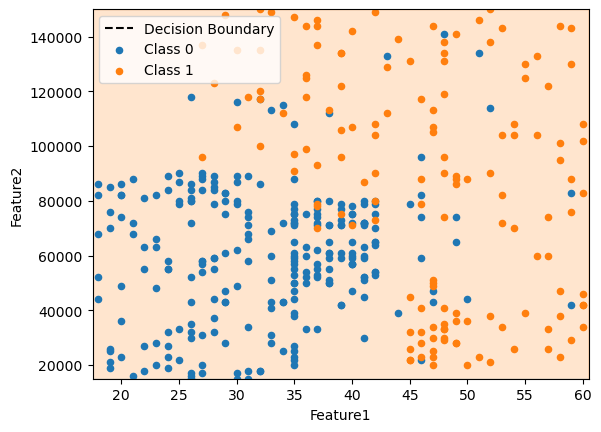

In [34]:
m = -final_w[0] / final_w[1]
c = -final_b / final_w[1]

xmin, xmax = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
ymin, ymax = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
xd = np.array([xmin, xmax])
yd = m * xd + c

plt.plot(xd, yd, 'k', ls='--', label='Decision Boundary')
plt.fill_between(xd, yd, ymin, color='tab:blue', alpha=0.2)
plt.fill_between(xd, yd, ymax, color='tab:orange', alpha=0.2)

plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], color='tab:blue', label='Class 0', s=20)
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], color='tab:orange', label='Class 1', s=20)
plt.legend()
plt.xlabel('Feature1')
plt.ylabel('Feature2')
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.show()